In [1]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/content/linearly_separable_data.csv")

In [3]:
df.head()

,feature1,feature2,output
0,0.496714,-1.415371,0.0
1,-0.138264,-0.420645,0.0
2,0.647689,-0.342715,0.0
3,1.523030,-0.802277,0.0
4,-0.234153,-0.161286,0.0


In [4]:
df.isnull().sum()

,0
feature1,0
feature2,0
output,0


In [5]:
X = df[['feature1', 'feature2']]
y = df['output']

In [6]:
#splitting the datasegt
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
#scaling it to ensure that no single feature is dominant
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
#creating the perceptron
perceptron = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)
#training it
perceptron.fit(X_train, y_train)

Perceptron(eta0=0.1, random_state=42)

In [10]:
y_pred = perceptron.predict(X_test)

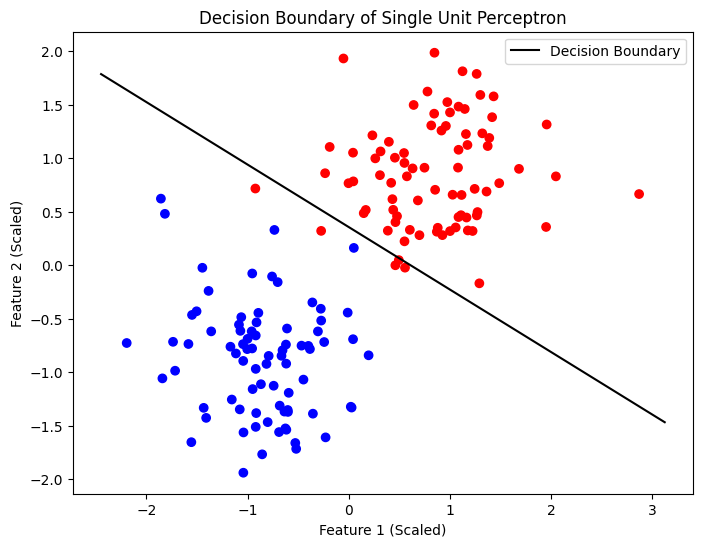

In [11]:
# plotting the perceptron
plt.figure(figsize=(8,6))

plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr')

ax = plt.gca()
xlim = ax.get_xlim()

xx = np.linspace(xlim[0], xlim[1], 100)

yy = -(perceptron.coef_[0][0] * xx + perceptron.intercept_[0]) / perceptron.coef_[0][1]

plt.plot(xx, yy, 'k-', label='Decision Boundary')

plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.title("Decision Boundary of Single Unit Perceptron")

plt.legend()

plt.show()